<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción al Análisis Exploratorio de Datos (EDA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/01_introduccion_eda.ipynb)

In [3]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [7]:
# Importación de librerías específicas para este notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

# Introducción al Análisis Exploratorio de Datos (EDA)

## RA1 - Trabajo práctico N° 2, grupo N° 8

Tipos de datos o variables

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Carga y Exploración Inicial

Primero, cargamos los datos y damos un "vistazo" rápido a su estructura. Usamos `pandas`, la librería por excelencia para el manejo de datos tabulares en Python.

In [8]:
# Esta función engloba código reutilizable para la gestión y carga de los datos
from utils.data import load_dataset

dataset_path = "/content/drive/MyDrive/datasets/immobiliaria/propiedades.csv"
dataset = pd.read_csv(dataset_path)

# Pandas hace la magia, una carga directa se ve así:

In [9]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
dataset.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


In [10]:
# Resumen de los tipos de datos y recuento de valores no nulos
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


Observamos que algunas columnas son de tipo `object` (strings categóricos), otras `int64` (enteros) y `float64` (decimales).
¡Tenemos datos faltantes!
precio 32


In [11]:
# Descriptores estadísticos básicos para las columnas numéricas
dataset.describe()

,id,precio,superficie_m2,habitaciones,antiguedad_años,precio_m2
count,800.0000,768.000000,800.00000,800.000000,752.000000,768.000000
mean,400.5000,200636.743398,117.63600,3.428750,21.960106,1961.878724
std,231.0844,142582.538365,154.54675,1.625801,18.556668,988.500261
min,1.0000,19900.000000,28.00000,1.000000,0.000000,116.180000
25%,200.7500,102900.000000,62.67500,2.000000,4.000000,1322.425000
50%,400.5000,160000.000000,90.95000,3.000000,18.000000,1841.940000
75%,600.2500,264075.000000,129.27500,5.000000,38.000000,2436.200000
max,800.0000,994200.000000,2700.00000,7.000000,59.000000,10111.360000


---
##Estadistica Descriptiva

• ¿Qué variables presentan mayor variabilidad relativa? Considerar el coeficiente de variación además de la desviación estándar.

In [14]:
numerical_cols = dataset.select_dtypes(include=['number']).columns

# Calcular la media y la desviación estándar para cada columna numérica
mean_values = dataset[numerical_cols].mean()
std_values = dataset[numerical_cols].std()

# CV = Desviación Estándar / Media
coefficient_of_variation = (std_values / mean_values)

# Crear un DataFrame para mostrar los resultados de manera ordenada
cv_df = pd.DataFrame({
    'Media': mean_values,
    'Desviación Estándar': std_values,
    'Coeficiente de Variación': coefficient_of_variation
}).sort_values(by='Coeficiente de Variación', ascending=False)

display(cv_df)

,Media,Desviación Estándar,Coeficiente de Variación
superficie_m2,117.636000,154.546750,1.313771
antiguedad_años,21.960106,18.556668,0.845017
precio,200636.743398,142582.538365,0.710650
id,400.500000,231.084400,0.576990
precio_m2,1961.878724,988.500261,0.503854
habitaciones,3.428750,1.625801,0.474167


La variable que presenta mayor variabilidad relativa es la superficie de las viviendas, con un coeficiente de variación (CV) de 1.314, mientras que el CV del resto de variables esta entre 0.45 y 0.85.

• Para las variables numéricas relevantes, ¿existen diferencias importantes entre la media y la mediana? ¿Qué implica eso sobre la forma de la distribución subyacente?

In [18]:
numerical_cols = dataset.select_dtypes(include=['number']).columns

# Calcular la media y la mediana para cada columna numérica
mean_values = dataset[numerical_cols].mean()
median_values = dataset[numerical_cols].median()

# Calcular la diferencia absoluta entre la media y la mediana
difference = (mean_values - median_values).abs()

# Calcular la diferencia porcentual
percentage_difference = (difference / mean_values) * 100

# Crear un DataFrame para mostrar los resultados
differences_df = pd.DataFrame({
    'Media': mean_values,
    'Mediana': median_values,
    'Diferencia Absoluta (Media - Mediana)': difference,
    'Diferencia Porcentual (%)': percentage_difference
}).sort_values(by='Diferencia Porcentual (%)', ascending=False)

display(differences_df)

,Media,Mediana,Diferencia Absoluta (Media - Mediana),Diferencia Porcentual (%)
superficie_m2,117.636000,90.95,26.686000,22.685232
precio,200636.743398,160000.00,40636.743398,20.253889
antiguedad_años,21.960106,18.00,3.960106,18.033184
habitaciones,3.428750,3.00,0.428750,12.504557
precio_m2,1961.878724,1841.94,119.938724,6.113463
id,400.500000,400.50,0.000000,0.000000


Existe una diferencia significativa entre la media y la mediana en casi todas las variables, principalmente en la superficie, el precio y la antigüedad del mobiliario. Esto es un indicativo de que las distribuciones no son simétricas y están sesgadas. En este caso todas las medianas son menores que las medias, por lo que las distribuciones estan sesgadas hacia la derecha.

• ¿Qué puede decirse sobre la distribución del precio? ¿Se parece a alguna distribución conocida?

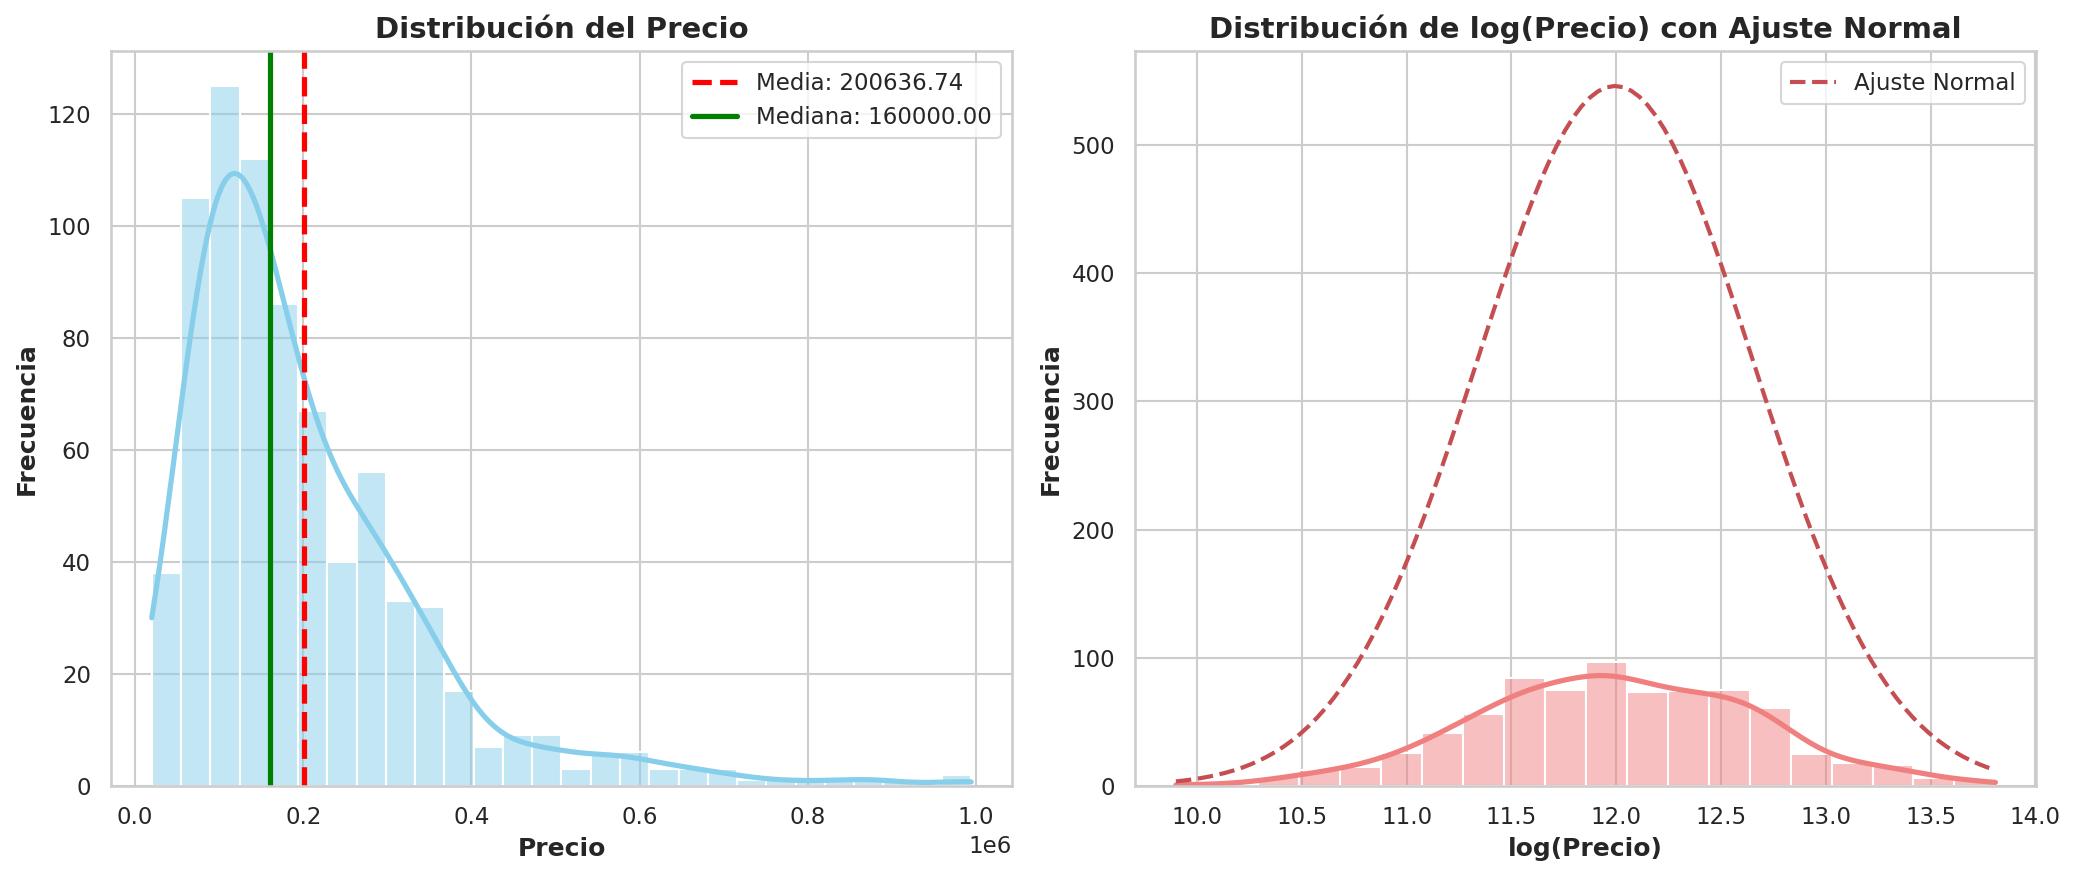

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Eliminar valores nulos de la columna 'precio' para el análisis
precio_data = dataset['precio'].dropna()

# Calcular media y mediana
mean_precio = precio_data.mean()
median_precio = precio_data.median()

# Crear la figura y los subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Distribución original del precio
sns.histplot(precio_data, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Precio')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')

# Añadir líneas de media y mediana al subplot 1
axes[0].axvline(mean_precio, color='red', linestyle='--', label=f'Media: {mean_precio:.2f}')
axes[0].axvline(median_precio, color='green', linestyle='-', label=f'Mediana: {median_precio:.2f}')
axes[0].legend()

# Subplot 2: Distribución de log(precio) y ajuste a una distribución normal
log_precio = np.log(precio_data)
sns.histplot(log_precio, kde=True, ax=axes[1], color='lightcoral')

# Ajustar una distribución normal a log_precio
mu, std = norm.fit(log_precio)
x_range = np.linspace(log_precio.min(), log_precio.max(), 100)
p_normal = norm.pdf(x_range, mu, std)

# Escalar la PDF para que se ajuste a la altura del histograma
max_hist_height = axes[1].patches[0].get_height() if axes[1].patches else 1
max_pdf_height = p_normal.max()
scale_factor = (max_hist_height / max_pdf_height) * (len(log_precio) * (log_precio.max() - log_precio.min()) / len(axes[1].get_xticks())) # Crude scaling

axes[1].plot(x_range, p_normal * scale_factor, 'r--', linewidth=2, label='Ajuste Normal')

axes[1].set_title('Distribución de log(Precio) con Ajuste Normal')
axes[1].set_xlabel('log(Precio)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

Es una distribución con una visible asimetría positiva, y se asemeja a la distribución Log-Normal. Esto representa que hay más propiedades de precios bajos, pero existen algunas de lujo o de precios muy altos (valores atípicos) que elevan el promedio, por lo que en este caso la mediana es una medida de tendencia central mas representativa que la media aritmética.



---



### 3. Tratamiento de Datos Faltantes (*Missing Values*)

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

In [ ]:
# Contabilizar valores nulos por columna
dataset.isna().sum()

,0
id,0
precio,32
superficie_m2,0
habitaciones,0
antiguedad_años,48
barrio,0
precio_m2,32


Según el contexto de nuestro problema (ver tarjeta del *dataset* en [*ACV Dataset*](https://github.com/AxelSkrauba/applied-ai-engineering/blob/main/datasets/acv/README.md)), en la variable `estado_fumador`, la categoría "desconocido" se utilizó para las entradas donde no había información. **Esto es funcionalmente un dato faltante** disfrazado de categoría. Vamos a exponerlo como tal para tratarlo correctamente.

In [13]:
# Reemplazamos "desconocido" por el valor nulo estándar de numpy (np.nan)
dataset['estado_fumador'] = dataset['estado_fumador'].replace('desconocido', np.nan)

# Calculamos el porcentaje de valores perdidos
miss_val_pct = dataset.isnull().sum() / len(dataset) * 100
print("Porcentaje de valores faltantes:")
print(miss_val_pct[miss_val_pct > 0].apply(lambda x: f"{x:.2f}%"))

KeyError: 'estado_fumador'

Para variables numéricas con bajo porcentaje de faltantes (como el `imc`, ~3.9%), una práctica común es **imputar** (rellenar) esos huecos con la **mediana** de la distribución, ya que es más robusta a *outliers* que la media.

Para variables categóricas con un alto porcentaje (como `estado_fumador`, ~30%), la decisión es más difícil. Podríamos imputar con la moda (el más frecuente), pero estaríamos sesgando mucho los datos. En este ejemplo didáctico, optaremos por **eliminar** las filas que no tengan esta información.

*Nota: En un escenario real estricto, descartar el 30% de los datos duele (en sentido figurado, por las dudas...). Se podrían usar técnicas avanzadas de imputación (ej: predecir el estado fumador basado en la edad y enfermedades).*

In [ ]:
# 1. Imputación de IMC con la mediana
mediana_imc = dataset['imc'].median()
dataset['imc'] = dataset['imc'].fillna(mediana_imc)

# 2. Descarte de filas con 'estado_fumador' nulo
dataset = dataset.dropna(subset=['estado_fumador'])

print(f"Filas restantes después de la limpieza: {len(dataset)}")
print(f"Valores nulos restantes:\n{dataset.isna().sum().sum()}")

### 4. Análisis de Distribuciones y Desbalance

Vamos a explorar cómo se distribuyen nuestras variables categóricas, prestando especial atención a nuestra variable objetivo (`apoplejia`).

In [ ]:
# Gráfico de pastel para el estado laboral
plt.figure(figsize=(6, 6))
dataset['tipo_trabajo'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3', ylabel='')
plt.title('Distribución por Tipo de Trabajo')
plt.show()

In [ ]:
# Verificamos el balance de nuestra variable a predecir
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x='apoplejia', palette='pastel')
plt.title('Distribución de Casos de ACV (0=No, 1=Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

casos_positivos = (dataset['apoplejia'] == 1).sum()
pct_positivos = casos_positivos / len(dataset) * 100
print(f"Casos positivos de ACV: {casos_positivos} ({pct_positivos:.2f}%)")

**¡Alerta de Desbalance!** ⚠️

Notamos que los casos positivos (ACV) representan una fracción mínima del *dataset* (apenas un ~5.6%). Este es un escenario muy común en salud, detección de fraudes y mantenimiento predictivo.
Si entrenamos un modelo así, probablemente aprenderá a predecir siempre "0" y logrará un 94% de precisión (Accuracy), siendo completamente inútil. En fases posteriores (Modelado) abordaremos técnicas como el submuestreo o SMOTE para lidiar con esto.

### 5. Detección de Valores Atípicos (*Outliers*)

Los *outliers* son valores que se desvían drásticamente del resto de la distribución. Pueden ser errores de carga de datos o anomalías reales muy raras. Usamos diagramas de caja (*Boxplots*) para detectarlos visualmente en las variables continuas.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=dataset['edad'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.boxplot(y=dataset['nivel_glucosa'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Nivel de Glucosa')

sns.boxplot(y=dataset['imc'], ax=axes[2], color='salmon')
axes[2].set_title('Distribución de IMC')

plt.tight_layout()
plt.show()

Observamos que no hay *outliers* evidentes en `edad`, pero sí muchos valores extremos altos en `nivel_glucosa` e `imc`.
*   Un `imc` cercano a 80-90 es biológicamente extremo (aunque posible en obesidad mórbida severa), pero podría ser un error tipográfico.
*   Un nivel de glucosa superior a 200 indica diabetes severa, lo cual es real y un fuerte factor de riesgo para ACV, por lo que **no deberíamos eliminarlos ciegamente**.

Para este ejercicio, filtramos (a modo de ejemplo) solo los valores de `imc` extremadamente dudosos (> 60).

In [ ]:
# Descarte condicional
dataset = dataset[dataset['imc'] <= 60]
print(f"Filas tras eliminar outliers de IMC: {len(dataset)}")

### 6. Relaciones entre Variables (Correlación)

Para entender cómo se relacionan las variables entre sí, podemos usar una matriz de correlación. Sin embargo, matemáticamente la correlación estándar (Pearson) se aplica a valores numéricos. Por lo tanto, debemos transformar nuestras variables categóricas (*strings*) a números temporales.

#### Tipos de Correlación (Mini Teoría)
- **Pearson**: Mide relaciones lineales. Ideal para distribuciones normales continuas.
- **Spearman**: Basado en rangos. Útil para relaciones monótonas (si uno sube, el otro también, pero no necesariamente en línea recta) o si hay muchos outliers.
- **Kendall**: Similar a Spearman, pero más robusto cuando el dataset es pequeño o hay muchos "empates" de valores.

Vamos a codificar rápidamente las categóricas usando `LabelEncoder` de `scikit-learn`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

dataset_encoded = dataset.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

En el mapa de calor, buscamos valores cercanos a 1 (correlación positiva fuerte) o -1 (correlación negativa fuerte).
*   Observamos una alta correlación (0.68) entre la `edad` y `casado_alguna_vez`. ¡Tiene todo el sentido lógico!
*   La variable objetivo `apoplejia` tiene sus mayores correlaciones positivas con la `edad` (0.24), el `nivel_glucosa` (0.13) y la presencia de `hipertension` (0.14) o `enfermedad_corazon` (0.14). Esto nos confirma que estas variables serán predictoras importantes para nuestros futuros modelos.

**NOTA**: para entender mejor las correlaciones, explorar el notebook [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)

## Resultados y Discusión

A partir de este EDA básico, hemos concluido que:
1. Nuestro *dataset* sufre de un **fuerte desbalance de clases**, requiriendo atención especial en la fase de modelado.
2. Identificamos y tratamos datos faltantes de manera fundamentada (imputación por mediana para numéricos, descarte para categóricos).
3. Confirmamos mediante correlaciones que factores biológicos como la edad, la glucosa y condiciones cardíacas preexistentes están ligados a la probabilidad de un ACV en nuestros datos.
4. Identificamos que variables como el `id` no aportan información y solo introducen ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** [Feature Engineering y Limpieza de Datos](02_feature_engineering_y_limpieza.ipynb).
- 🔄 **Relacionado:** Con el dataset limpio, estamos listos para entender qué hacen los modelos con esto [Introducción a la Clasificación](../03_machine_learning/01_introduccion_clasificacion.ipynb).

## Referencias
1. Dataset ACV: Healthcare Dataset Stroke Data (Kaggle).
2. [Documentación Oficial de Pandas](https://pandas.pydata.org/docs/)
3. [Documentación de Seaborn para Visualización Estadística](https://seaborn.pydata.org/)

---
## Entorno de Ejecución

In [ ]:
from utils.environment import environment_table
environment_table(include_all=False)